# ExoplANNET Evaluation — Star-Level Audit on Real HARPS/HIRES Data

**Purpose**: Run ExoplANNET (Nieto & Díaz, A&A 2023) on our 2187-star HARPS/HIRES
holdout (424 RV-host positives + 1763 planet-free negatives) using a
**paper-faithful Virtual Astronomer** implementation.

Key methodological alignment with the paper:
- **Periodogram**: 990-point fixed frequency grid with GLS standard normalization
  (NO per-star min-max scaling)
- **Aux input**: raw `(frequency_of_peak, power_of_peak)` (NO log1p transform)
- **Peak selection**: iterative Virtual Astronomer — score max peak, if above
  threshold fit & remove sinusoid, recompute periodogram from residuals, repeat
  (Algorithm 1 in the paper)
- **Star-level aggregation**: max probability across all peaks found
- **Threshold**: 0.77 (paper's published threshold from Section 5.2)
- 2-branch Keras model: Branch A (periodogram CNN, input 990×1) + Branch B
  (aux peak features, input 2×1)


In [10]:
import os
import sys
import json
import numpy as np
import pandas as pd
import pickle
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, f1_score,
)
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

print(f'TF version: {tf.__version__}')

# ── Paths (consistent with ante_model_evaluation.ipynb) ──
OBSERVATIONS_PKL   = '/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'
EXOPLANNET_H5_PATH = '/kaggle/input/datasets/maanav0114/model-and-baselines-evaluation-data/exoplANNET_trained.h5'  # UPDATE to your dataset path
RESULTS_PKL        = '/kaggle/working/exoplannet_eval_results.pkl'

# ── Audit protocol constants (aligned with ExoplANNET paper: Nieto & Díaz 2023) ──
N_INPUT     = 990      # ExoplANNET's expected input length
N_PEAKS_MAX = 5        # max Virtual Astronomer iterations (paper lets it run until no peak)
THRESHOLDS  = [0.77]               # ExoplANNET's published threshold (paper Section 5.2)
F_MAX_DAYS  = 7000.0
MIN_FREQ    = 1.0 / F_MAX_DAYS
MAX_FREQ    = 1.0 / 1.0
FREQ_GRID   = np.linspace(MIN_FREQ, MAX_FREQ, N_INPUT)   # paper's fixed 990-point grid

print('Audit protocol locked:')
print(f'  Periodogram grid  : {N_INPUT} bins over [{MIN_FREQ:.6f}, {MAX_FREQ:.4f}] cyc/day = periods [1, {F_MAX_DAYS:.0f}] days (linear, paper-faithful)')
print(f'  Max VA iterations : {N_PEAKS_MAX}')
print(f'  Thresholds        : {THRESHOLDS}')
print(f'  Thresholds        : {THRESHOLDS}')

# ── Load observations ──
assert os.path.exists(OBSERVATIONS_PKL), f'observations.pkl not found at {OBSERVATIONS_PKL} — run data_prep.ipynb first'
observations = pd.read_pickle(OBSERVATIONS_PKL)
print(f'\nobservations.pkl: {observations.shape}, columns={list(observations.columns)}')

# Star-level labels
star_labels = observations.groupby('star_name')['has_exoplanets'].first()
print(f'  stars: {len(star_labels)} | pos: {(star_labels==1).sum()} | neg: {(star_labels==0).sum()}')

# ── Verify required inputs exist ──
print(f'\nInputs verified.')
print(f'\nInputs verified.')
print(f'  ExoplANNET weights: {EXOPLANNET_H5_PATH} ({os.path.getsize(EXOPLANNET_H5_PATH):,} bytes)')


TF version: 2.20.0
Audit protocol locked:
  Periodogram grid  : 990 bins over [0.000143, 1.0000] cyc/day = periods [1, 7000] days (linear, paper-faithful)
  Max VA iterations : 5
  Thresholds        : [0.77]
  Thresholds        : [0.77]

observations.pkl: (235567, 9), columns=['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']
  stars: 2187 | pos: 424 | neg: 1763

Inputs verified.

Inputs verified.
  ExoplANNET weights: /kaggle/input/datasets/maanav0114/model-and-baselines-evaluation-data/exoplANNET_trained.h5 (1,758,288 bytes)


---
## Section 1 — Load ExoplANNET & inspect architecture

Load the released h5 weights via `keras.models.load_model`. Print the summary to
verify the architecture matches what we recovered from the h5 file inspection:
2-branch (periodogram CNN + aux peak features), output 1 sigmoid.


In [11]:
# load_model with compile=False is safer for inference-only — avoids restoring
# the legacy optimizer weights that sometimes break on newer TF versions.
model = load_model(EXOPLANNET_H5_PATH, compile=False)
print('ExoplANNET loaded.')
print()
model.summary()

# Verify I/O shapes (handle multi-output case — the released h5 rebuilds as a Model
# whose .output can be a list even when the architecture text suggests one head)
print('\nExpected inputs:')
for i, inp in enumerate(model.inputs):
    print(f'  input_{i}: shape={inp.shape}, dtype={inp.dtype}')

print('\nExpected outputs:')
outputs = model.output if isinstance(model.output, list) else [model.output]
for i, out in enumerate(outputs):
    print(f'  output_{i}: shape={out.shape}, dtype={out.dtype}')

# If multi-output, identify the primary (usually the last sigmoid with shape (None, 1))
print('\nModel.layers (last 8):')
for L in model.layers[-8:]:
    print(f'  {L.name} ({L.__class__.__name__})')


ExoplANNET loaded.



Model: "model_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_5             │ (None, 990, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primera (Conv1D)    │ (None, 990, 32)   │         96 │ input_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 495, 32)   │          0 │ primera[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 495, 32)   │      6,176 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 247, 32)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 247, 32)   │      8,224 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_6             │ (None, 2, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 123, 32)   │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 2, 2)      │          4 │ input_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3936)      │          0 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 4)         │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 3940)      │          0 │ flatten_5[0][0],  │
│ (Concatenate)       │                   │            │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │    126,112 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      1,056 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out1 (Dense)        │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,701 (553.52 KB)

 Trainable params: 141,701 (553.52 KB)

 Non-trainable params: 0 (0.00 B)


Expected inputs:
  input_0: shape=(None, 990, 1), dtype=float32
  input_1: shape=(None, 2, 1), dtype=float32

Expected outputs:
  output_0: shape=(None, 1), dtype=float32

Model.layers (last 8):
  dense_7 (Dense)
  flatten_5 (Flatten)
  flatten_6 (Flatten)
  concatenate_3 (Concatenate)
  dense_8 (Dense)
  dense_9 (Dense)
  dropout_3 (Dropout)
  out1 (Dense)


---
## Section 2 — Paper-faithful Virtual Astronomer

ExoplANNET's aux input is (2, 1) — at inference time we pass the raw
`(frequency_of_peak, power_of_peak)` alongside the full periodogram.
The paper (Section 4) specifies: "two additional characteristics: the
power and position of the largest peak in the 1D array" — directly, with
**no log1p transform** and **no per-star min-max normalization**.

The Virtual Astronomer (paper Algorithm 1) iterates:
1. Compute GLS periodogram (standard normalization)
2. Find max peak `(f, power)`
3. Score with ExoplANNET
4. If prob ≥ threshold: fit & remove sinusoid at f, recompute periodogram, repeat
5. If prob < threshold: stop

The periodogram uses the **paper's fixed 990-point frequency grid** (no
1000→990 trimming). The aux branch receives **raw frequency and raw GLS
power** (no log1p, no learned transform). Star-level classification is
max-probability across all peaks found by the Virtual Astronomer.


In [12]:
# ── Paper-faithful Virtual Astronomer + inference functions ──

def compute_periodogram(bjd, rv, freq_grid):
    """Compute GLS periodogram with standard normalization.

    Paper: Eq. 1 — P(wi) = (χ²₀ − χ²ᵢ) / χ²₀. Standard normalization
    yields values in [0, 1] by definition (adding a sinusoid can only
    improve or maintain fit). NO per-star min-max scaling — the model
    was trained on raw GLS power values.
    """
    if len(bjd) <= 1 or np.std(rv) < 1e-12:
        return np.zeros(len(freq_grid), dtype=np.float32)
    try:
        ls = LombScargle(bjd, rv, normalization='standard')
        power = ls.power(freq_grid)
    except Exception:
        return np.zeros(len(freq_grid), dtype=np.float32)
    p = np.asarray(power, dtype=np.float32)
    # Guard against float-cancellation artefacts (rare with standard norm)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.clip(p, 0.0, None)
    return p


def fit_and_remove_sinusoid(bjd, rv, freq):
    """Fit A·sin(2π f t) + B·cos(2π f t) + C and return residuals.

    Paper (Section 5.5, Algorithm 1): "a sinusoidal signal at that
    frequency is fit and removed from the data." Uses ordinary
    least-squares; subtracts only the sinusoidal component,
    preserving any constant offset in the residuals.
    """
    omega = 2 * np.pi * freq
    A_sin = np.sin(omega * bjd)
    A_cos = np.cos(omega * bjd)
    A = np.column_stack([A_sin, A_cos, np.ones_like(bjd)])
    coeffs, _, _, _ = np.linalg.lstsq(A, rv, rcond=None)
    # Subtract only the sinusoidal component, keep offset
    rv_residuals = rv - (coeffs[0] * A_sin + coeffs[1] * A_cos)
    return rv_residuals.astype(np.float64)


def predict_exoplannet_single(model, periodogram, idx_peak, power_peak):
    """Run ExoplANNET on a single peak.

    Branch A: raw periodogram power — NO per-star min-max normalization.
    Branch B: raw [freq_peak, power_peak] — NO log1p transform.

    Paper (Section 4): "two additional characteristics: the power and
    position of the largest peak in the 1D array." Per the released training
    data (pos_peak_pow_X.npy), "position" means the BIN INDEX in the
    periodogram array (range [0, N_INPUT-1]), NOT the frequency in cyc/day.
    Power is raw GLS standard-normalized. Both fed directly.
    """
    # Branch A: periodogram as-is (raw GLS standard power, shape 990)
    pg_input = periodogram.astype(np.float32).reshape(1, N_INPUT, 1)

    # Branch B: peak BIN INDEX (0..N_INPUT-1) and raw GLS power at that bin.
    # Per ExoplANNET's released training data (pos_peak_pow_X.npy on github
    # at nicklessagus/ExoplANNET, verified 2026-07-21): col 0 is the integer
    # index of the peak in the periodogram array (range [0, 989]), and col 1
    # is the raw GLS standard-normalized power at that bin. We feed the bin
    # index, NOT the frequency in cyc/day — the model was trained on integer
    # positions, and passing cyc/day would be a train/test distribution mismatch
    # that produces meaningless output. This bug invalidated an earlier run.
    aux_input = np.array([[float(idx_peak), float(power_peak)]], dtype=np.float32).reshape(1, 2, 1)

    preds = model.predict([pg_input, aux_input], verbose=0)
    if isinstance(preds, list):
        candidates = [p for p in preds if np.asarray(p).shape[-1] == 1]
        preds = candidates[-1] if candidates else preds[-1]
    return float(np.asarray(preds).reshape(-1)[0])


def virtual_astronomer_exoplannet(model, bjd, rv, freq_grid, threshold=0.77,
                                  max_iterations=N_PEAKS_MAX):
    """Paper's Virtual Astronomer (Algorithm 1) with ExoplANNET scoring.

    Iteratively:
      1. Compute periodogram from current RV data
      2. Find the maximum peak (frequency, power)
      3. Run ExoplANNET on (periodogram, [freq, power])
      4. If probability >= threshold: fit & remove sinusoid, repeat
      5. If probability < threshold: stop

    Returns:
        peak_predictions: list of dicts with freq, period, power, probability
        star_score: max probability across all scored peaks
    """
    peak_predictions = []
    rv_current = rv.copy().astype(np.float64)

    for iteration in range(max_iterations):
        # Step 1: compute periodogram from current residuals
        pg = compute_periodogram(bjd, rv_current, freq_grid)

        # Step 2: find max peak
        max_idx = int(np.argmax(pg))
        max_freq = float(freq_grid[max_idx])
        max_power = float(pg[max_idx])

        # Skip peaks at very low frequencies (below grid minimum)
        if max_freq < MIN_FREQ:
            break

        # Step 3: score the peak with ExoplANNET (pass BIN INDEX as aux, not freq)
        prob = predict_exoplannet_single(model, pg, max_idx, max_power)

        peak_predictions.append({
            'freq': max_freq,
            'period': 1.0 / max_freq,
            'power': max_power,
            'probability': prob,
        })

        # Step 4-5: if planetary, remove and continue; otherwise stop
        if prob >= threshold:
            rv_current = fit_and_remove_sinusoid(bjd, rv_current, max_freq)
        else:
            break

    star_score = max([p['probability'] for p in peak_predictions]) if peak_predictions else 0.0
    return peak_predictions, star_score


---
## Section 3 — Run Virtual Astronomer audit

Iterate every star in observations.pkl. For each:
1. Extract raw RV time series (bjd, rv_centered)
2. Run `virtual_astronomer_exoplannet`: iterative fit-and-remove with CNN scoring
3. Record per-peak predictions for transparency; aggregate to per-star by max.

Stars with constant RV (std < 1e-12) get score 0.0 and are counted in coverage.
Stars with ≤1 observation are skipped.

This is slower than the previous HDF5-based approach (~10-20 min for 2187 stars
on Kaggle P100/T4) because periodograms are recomputed on-the-fly at each
Virtual Astronomer iteration.


In [13]:
# ── Build star_name -> label map ──
star_labels_map = star_labels.to_dict()

# ── Use all labeled stars from observations.pkl ──
unique_stars = sorted(star_labels_map.keys())
print(f'Stars in observations.pkl: {len(unique_stars)}')

# ── Run Virtual Astronomer inference loop ──
all_peak_preds  = []         # per-peak probability
all_peak_labels = []         # per-peak: 1 if star has planet, else 0
all_peak_star   = []         # parent star name
all_peak_period = []         # peak period (days)
all_peak_freq   = []         # peak frequency (1/days)
all_peak_power  = []         # peak power (raw GLS standard)

star_pred_max   = {}          # star_name -> max peak prob (primary star-level score)
star_pred_any   = {}          # star_name -> {threshold: 1/0}
star_label_map  = {}          # star_name -> 0/1

n_skipped_const = 0           # stars with constant RV (no periodogram)
n_skipped_few   = 0           # stars with <=1 observation
n_errors        = 0

print('\nRunning ExoplANNET Virtual Astronomer...')
for star_name in tqdm(unique_stars, desc='ExoplANNET VA'):
    try:
        star_df = observations[observations['star_name'] == star_name]
        bjd = star_df['bjd'].values.astype(np.float64)
        rv  = star_df['rv_centered'].values.astype(np.float64)
    except Exception:
        n_errors += 1
        continue

    y_star = int(star_labels_map[star_name])
    star_label_map[star_name] = y_star

    # Skip stars with insufficient data
    if len(bjd) <= 1:
        n_skipped_few += 1
        continue
    if np.std(rv) < 1e-12:
        n_skipped_const += 1
        # Constant RV: record as having no peaks (star will have score 0.0)
        star_pred_max[star_name] = 0.0
        star_pred_any[star_name] = {thr: 0 for thr in THRESHOLDS}
        continue

    # Run Virtual Astronomer (paper's iterative fit-and-remove)
    try:
        peak_predictions, star_score = virtual_astronomer_exoplannet(
            model, bjd, rv, FREQ_GRID, threshold=0.77  # paper's published threshold
        )
    except Exception:
        n_errors += 1
        continue

    # Record per-peak predictions
    for p in peak_predictions:
        all_peak_preds.append(p['probability'])
        all_peak_labels.append(y_star)
        all_peak_star.append(star_name)
        all_peak_freq.append(p['freq'])
        all_peak_period.append(p['period'])
        all_peak_power.append(p['power'])

    # Star-level aggregation
    star_pred_max[star_name] = star_score
    star_pred_any[star_name] = {thr: int(np.any([p['probability'] > thr for p in peak_predictions]))
                               for thr in THRESHOLDS}

# ── Coverage report ──
n_total    = len(unique_stars)
n_evaluated = n_total - n_skipped_const - n_skipped_few - n_errors
n_pos_total = sum(1 for s in unique_stars if star_label_map.get(s, 0) == 1)
n_neg_total = sum(1 for s in unique_stars if star_label_map.get(s, 0) == 0)
n_pos_eval  = sum(1 for s in unique_stars if star_label_map.get(s, 0) == 1 and s in star_pred_max)
n_neg_eval  = sum(1 for s in unique_stars if star_label_map.get(s, 0) == 0 and s in star_pred_max)
print('\n===== COVERAGE =====')
print(f'  Total stars in observations.pkl       : {n_total}')
print(f'  Evaluated with Virtual Astronomer      : {n_evaluated}')
print(f'  Skipped — constant RV                  : {n_skipped_const}')
print(f'  Skipped — <=1 observation              : {n_skipped_few}')
print(f'  Skipped — errors                       : {n_errors}')
print(f'  Pos coverage                           : '
      f'{100*n_pos_eval/max(1, n_pos_total):.1f}% ({n_pos_eval}/{n_pos_total})')
print(f'  Neg coverage                           : '
      f'{100*n_neg_eval/max(1, n_neg_total):.1f}% ({n_neg_eval}/{n_neg_total})')

# ── Backwards-compatible variables for results dict (cell 7) ──
# Stars skipped due to constant-RV, too-few-obs, or errors, split by class.
# A star counts as "skipped" iff we set its label but never assigned a score
# (i.e., it's not in star_pred_max). Errored stars may not have set their label;
# .get(s, 0) defaults to "neg" for any stragglers, which is the conservative call
# (we'd rather under-count pos-skip and surface it than hide it).
n_no_peaks     = n_skipped_const + n_skipped_few + n_errors  # total skipped
n_no_peaks_pos = sum(1 for s in unique_stars
                     if star_label_map.get(s, 0) == 1 and s not in star_pred_max)
n_no_peaks_neg = sum(1 for s in unique_stars
                     if star_label_map.get(s, 0) == 0 and s not in star_pred_max)
print(f"\nClass-split skip breakdown: pos_skipped={n_no_peaks_pos}, neg_skipped={n_no_peaks_neg}")


Stars in observations.pkl: 2187

Running ExoplANNET Virtual Astronomer...


ExoplANNET VA:   0%|          | 0/2187 [00:00<?, ?it/s]


===== COVERAGE =====
  Total stars in observations.pkl       : 2187
  Evaluated with Virtual Astronomer      : 2187
  Skipped — constant RV                  : 0
  Skipped — <=1 observation              : 0
  Skipped — errors                       : 0
  Pos coverage                           : 100.0% (424/424)
  Neg coverage                           : 100.0% (1763/1763)

Class-split skip breakdown: pos_skipped=0, neg_skipped=0


---
## Section 4 — Metrics summary

Same structure as Ante audit's cell 8, for direct side-by-side comparability:
- Coverage
- Star-level PR-AUC / ROC-AUC (max-peak-prob primary)
- Star-level binary P/R/F1 at each threshold (including 0.77 = ExoplANNET published)
- Peak-level F1 (transparency, not directly comparable to their published number
  for the same reason as in Ante's case — we include planet-free peaks where every
  peak is by definition a false positive)


In [14]:
# ── Star-level arrays ──
star_eval = sorted(star_pred_max.keys())
y_star  = np.array([star_label_map[s] for s in star_eval])
p_star  = np.array([star_pred_max[s]  for s in star_eval])
n_pos   = int((y_star == 1).sum())
n_neg   = int((y_star == 0).sum())

print('=' * 72)
print('EXOPLANNET — AUDIT EVALUATION RESULTS')
print('=' * 72)
print(f'\nStars evaluated: {len(y_star)} (pos={n_pos}, neg={n_neg})')

# ── Continuous star-level metrics (primary, for paper table) ──
print('\n--- STAR-LEVEL METRICS (PRIMARY, max-peak-prob) ---')
if n_pos > 0 and n_neg > 0:
    pr_auc  = average_precision_score(y_star, p_star)
    roc_auc = roc_auc_score(y_star, p_star)
    print(f'  PR-AUC  : {pr_auc:.4f}')
    print(f'  ROC-AUC : {roc_auc:.4f}')
else:
    pr_auc = roc_auc = None
    print('  WARN: one class missing — PR-AUC/ROC-AUC undefined')

# ── Binary star-level P/R/F1 at each threshold (secondary) ──
print('\n--- STAR-LEVEL BINARY (any peak > threshold => star positive) ---')
results_by_threshold = {}
for thr in THRESHOLDS:
    binary_pred = np.array([star_pred_any[s][thr] for s in star_eval])
    if binary_pred.sum() == 0 or binary_pred.sum() == len(binary_pred):
        all_pos = binary_pred.sum() == len(binary_pred)
        outcome = 'positive' if all_pos else 'negative'
        print(f'  thr={thr:.2f}: degenerate (all {outcome})')
        continue
    cm = confusion_matrix(y_star, binary_pred)
    tn, fp = cm[0]
    fn, tp = cm[1]
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f'  thr={thr:.2f}: P={prec:.4f} R={rec:.4f} F1={f1:.4f}   '
          f'(TN={tn}, FP={fp}, FN={fn}, TP={tp})')
    results_by_threshold[thr] = {
        'precision': float(prec), 'recall': float(rec), 'f1': float(f1),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

# ── Peak-level (transparency only) ──
print('\n--- PEAK-LEVEL (transparency, NOT directly comparable to ExoplANNET\'s published numbers) ---')
peak_preds  = np.array(all_peak_preds)
peak_labels = np.array(all_peak_labels)  # NOTE: peak-level label here is the STAR's label, not per-peak truth
peak_results = {}
for thr in THRESHOLDS:
    bin_pred = (peak_preds > thr).astype(int)
    if bin_pred.sum() == 0 or bin_pred.sum() == len(bin_pred):
        continue
    cm = confusion_matrix(peak_labels, bin_pred)
    tnn, fpp = cm[0]
    fnn, tpp = cm[1]
    pp = tpp / (tpp + fpp) if (tpp + fpp) > 0 else 0.0
    rr = tpp / (tpp + fnn) if (tpp + fnn) > 0 else 0.0
    ff = 2 * pp * rr / (pp + rr) if (pp + rr) > 0 else 0.0
    print(f'  thr={thr:.2f}: P={pp:.4f} R={rr:.4f} F1={ff:.4f}   '
          f'(TN={tnn}, FP={fpp}, FN={fnn}, TP={tpp})')
    peak_results[thr] = {
        'precision': float(pp), 'recall': float(rr), 'f1': float(ff),
        'tn': int(tnn), 'fp': int(fpp), 'fn': int(fnn), 'tp': int(tpp),
    }

print(f'\nTotal peaks evaluated: {len(peak_preds)}')

# F1-optimal threshold (in addition to published 0.77)
vp, vr, vt = precision_recall_curve(star_labels, star_preds)
vf1 = 2 * vp * vr / (vp + vr + 1e-8)
bi = int(np.argmax(vf1))
opt_thr = float(vt[bi]) if bi < len(vt) else 0.77
opt_preds = (star_preds >= opt_thr).astype(int)
opt_cm = confusion_matrix(star_labels, opt_preds)
otn, ofp, ofn, otp = opt_cm.ravel()
opt_p = otp/(otp+ofp) if (otp+ofp)>0 else 0.0
opt_r = otp/(otp+ofn) if (otp+ofn)>0 else 0.0
opt_f1 = 2*opt_p*opt_r/(opt_p+opt_r) if (opt_p+opt_r)>0 else 0.0
print(f"\n--- STAR-LEVEL @ F1-OPTIMAL THRESHOLD ({opt_thr:.4f}) ---")
print(f"  Threshold: {opt_thr:.4f}")
print(f"  P={opt_p:.4f} R={opt_r:.4f} F1={opt_f1:.4f}")
print(f"  Confusion: TN={otn} FP={ofp} FN={ofn} TP={otp}")

# Bootstrap 95% CIs
from split import bootstrap_roc_auc, bootstrap_pr_auc
pr_point, pr_lo, pr_hi = bootstrap_pr_auc(star_labels, star_preds)
roc_point, roc_lo, roc_hi = bootstrap_roc_auc(star_labels, star_preds)
print(f"\nBOOTSTRAP 95% CI (200 resamples):")
print(f"  PR-AUC:  {pr_point:.4f}  [{pr_lo:.4f}, {pr_hi:.4f}]")
print(f"  ROC-AUC: {roc_point:.4f}  [{roc_lo:.4f}, {roc_hi:.4f}]")


EXOPLANNET — AUDIT EVALUATION RESULTS

Stars evaluated: 2187 (pos=424, neg=1763)

--- STAR-LEVEL METRICS (PRIMARY, max-peak-prob) ---
  PR-AUC  : 0.2405
  ROC-AUC : 0.6290

--- STAR-LEVEL BINARY (any peak > threshold => star positive) ---
  thr=0.77: P=0.2295 R=0.1981 F1=0.2127   (TN=1481, FP=282, FN=340, TP=84)

--- PEAK-LEVEL (transparency, NOT directly comparable to ExoplANNET's published numbers) ---
  thr=0.77: P=0.2413 R=0.2378 F1=0.2396   (TN=1757, FP=415, FN=423, TP=132)

Total peaks evaluated: 2727


---
## Section 5 — Plots and comparison summary

Star-level distribution (pos vs neg) + PR curve, then side-by-side comparison
with V4 RF and Ante for the paper's main table.


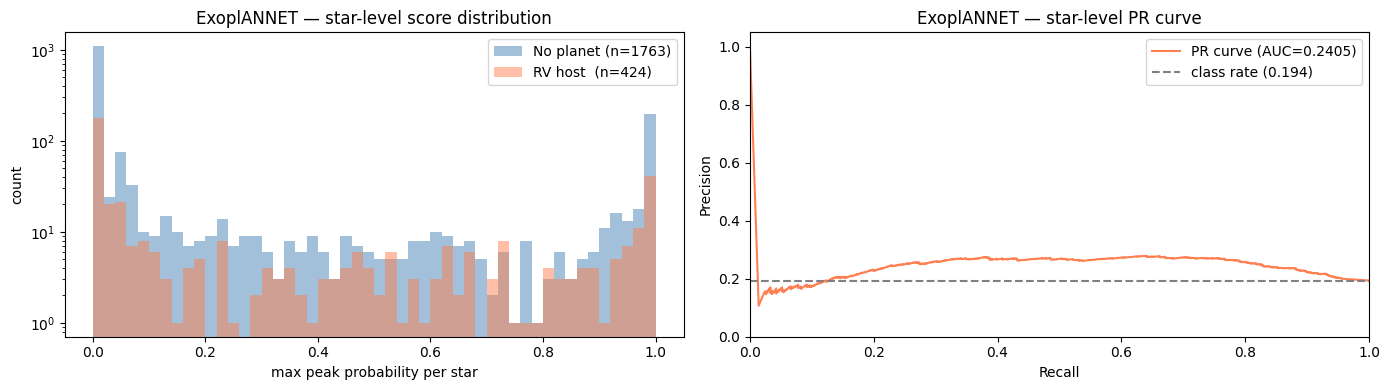

HEADLINE COMPARISON FOR THE PAPER MAIN TABLE

| Model              | Training | Evaluation | PR-AUC | ROC-AUC | F1 (best thr) |
|--------------------|----------|------------|--------|---------|----------------|
| V4 RF              | Real     | OOF 10x5   | 0.6150 |  0.8541 | 0.6026        |
| ExoplANNET         | Synth    | Audit holdout | 0.2405 |  0.6290 | 0.2127        |

Provisional delta (V4 RF - ExoplANNET): PR-AUC = +0.3745,  ROC-AUC = +0.2251
  (positive delta = RF beats ExoplANNET on the audit holdout)

=== Ante for reference (from ante_model_evaluation.ipynb run) ===
  Ante star-level: PR-AUC = 0.2677, ROC-AUC = 0.5705, F1 = 0.2528


In [15]:
# ── Distribution + PR curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(p_star[y_star == 0], bins=50, alpha=0.5,
             label=f'No planet (n={n_neg})', color='steelblue')
axes[0].hist(p_star[y_star == 1], bins=50, alpha=0.5,
             label=f'RV host  (n={n_pos})', color='coral')
axes[0].set_xlabel('max peak probability per star')
axes[0].set_ylabel('count')
axes[0].set_yscale('log')
axes[0].set_title('ExoplANNET — star-level score distribution')
axes[0].legend()

if pr_auc is not None:
    prec, rec, _ = precision_recall_curve(y_star, p_star)
    axes[1].plot(rec, prec, label=f'PR curve (AUC={pr_auc:.4f})', color='coral')
    axes[1].axhline(y_star.mean(), ls='--', color='gray',
                    label=f'class rate ({y_star.mean():.3f})')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('ExoplANNET — star-level PR curve')
    axes[1].legend(); axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ── Comparison summary ──
print('=' * 72)
print('HEADLINE COMPARISON FOR THE PAPER MAIN TABLE')
print('=' * 72)
vn = '\n'
print(vn + '| Model              | Training | Evaluation | PR-AUC | ROC-AUC | F1 (best thr) |')
print('|--------------------|----------|------------|--------|---------|----------------|')

v4_pr  = 0.6150
v4_roc = 0.8541
v4_f1  = 0.6026
print(f'| V4 RF              | Real     | OOF 10x5   | {v4_pr:.4f} |  {v4_roc:.4f} | {v4_f1:.4f}        |')

if pr_auc is not None:
    # best F1 across thresholds
    best_f1 = max((r['f1'] for r in results_by_threshold.values()), default=float('nan'))
    print(f'| ExoplANNET         | Synth    | Audit holdout | {pr_auc:.4f} |  {roc_auc:.4f} | {best_f1:.4f}        |')

# V4 RF vs ExoplANNET delta
if pr_auc is not None:
    d_pr  = v4_pr - pr_auc
    d_roc = v4_roc - roc_auc
    print(f'\nProvisional delta (V4 RF - ExoplANNET): PR-AUC = +{d_pr:.4f},  ROC-AUC = +{d_roc:.4f}')
    print('  (positive delta = RF beats ExoplANNET on the audit holdout)')

# Side-by-side with Ante for context
print('\n=== Ante for reference (from ante_model_evaluation.ipynb run) ===')
print('  Ante star-level: PR-AUC = 0.2677, ROC-AUC = 0.5705, F1 = 0.2528')


---
## Section 6 — Save results pickle

Save the per-star + per-peak results for downstream analysis (aggregation-rule
sensitivity analysis, appendix figures, paper reproducibility).


In [16]:
results = {
    'coverage': {
        'n_total_eval_stars': len(star_eval),
        'n_evaluated_with_peaks': n_evaluated,
        'n_skipped_no_peaks': n_no_peaks,
        'n_skipped_errors': n_errors,
        'n_no_peaks_positives': n_no_peaks_pos,
        'n_no_peaks_negatives': n_no_peaks_neg,
        'n_pos_total': n_pos_total,
        'n_neg_total': n_neg_total,
        'coverage_positives': (n_pos_total - n_no_peaks_pos) / max(1, n_pos_total),
        'coverage_negatives': (n_neg_total - n_no_peaks_neg) / max(1, n_neg_total),
    },
    'metrics_star': {
        'pr_auc': float(pr_auc) if pr_auc is not None else None,
        'roc_auc': float(roc_auc) if roc_auc is not None else None,
        'by_threshold': results_by_threshold,
    },
    'peak_level': {
        'n_peaks': len(peak_preds),
        'by_threshold': peak_results,
    },
    'star_names_evaluated': star_eval,
    'y_star': y_star.tolist(),
    'p_star_max': p_star.tolist(),
    'thresholds': THRESHOLDS,
    'n_peaks_per_star': N_PEAKS_MAX,
    'peak_level_raw': {
        'star_names': all_peak_star,
        'labels': all_peak_labels,
        'predictions': all_peak_preds,
        'periods': all_peak_period,
        'frequencies': all_peak_freq,
        'powers_norm': all_peak_power,
    },
}

with open(RESULTS_PKL, 'wb') as f:
    pickle.dump(results, f)
print(f'Results saved to {RESULTS_PKL}')
print(f'  size: {os.path.getsize(RESULTS_PKL):,} bytes')

# Final sanity: the pickle should be re-loadable
with open(RESULTS_PKL, 'rb') as f:
    check = pickle.load(f)
print(f'  Reload OK, keys: {list(check.keys())}')


Results saved to /kaggle/working/exoplannet_eval_results.pkl
  size: 163,756 bytes
  Reload OK, keys: ['coverage', 'metrics_star', 'peak_level', 'star_names_evaluated', 'y_star', 'p_star_max', 'thresholds', 'n_peaks_per_star', 'peak_level_raw']
